In [1]:
# Package imports
import numpy as np
import matplotlib.pyplot as plt
from testCases_v2 import *
import sklearn
import sklearn.datasets
import sklearn.linear_model
from planar_utils import plot_decision_boundary, sigmoid, load_planar_dataset, load_extra_datasets

%matplotlib inline

np.random.seed(1) # set a seed so that the results are consistent

In [2]:
X, y = load_planar_dataset()

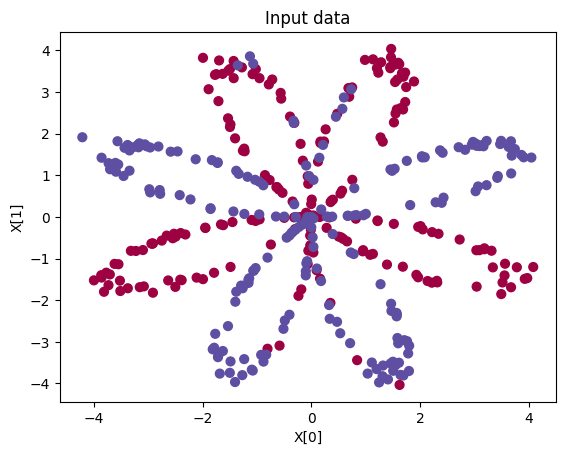

In [3]:
plt.scatter(X[0, :], X[1, :], c=y, s=40, cmap=plt.cm.Spectral)
plt.title("Input data")
plt.xlabel("X[0]")
plt.ylabel("X[1]")
plt.show()

In [4]:
shape_X = X.shape
shape_y = y.shape
m = shape_X[1]
print(f"X.shape: {shape_X}")
print(f"y.shape: {shape_y}")
print(f"Number of training examples: {m}")

X.shape: (2, 400)
y.shape: (1, 400)
Number of training examples: 400


w: [[ 0.02780872 -0.20164061]]
b: [0.01542522]


/home/nafiz/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


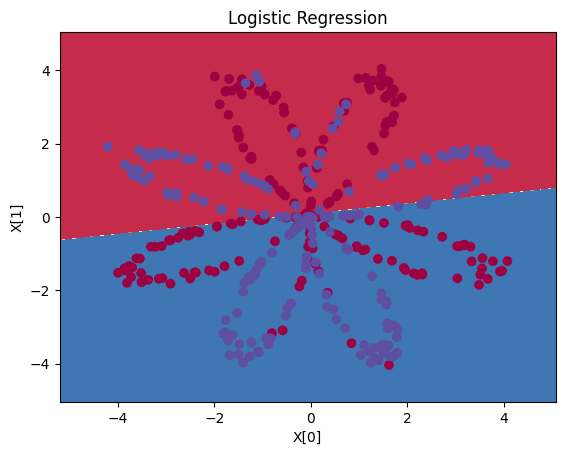

Training accuracy: 0.47


/tmp/ipykernel_16511/452172449.py:13: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  accuracy = float(np.dot(y, predictions) + np.dot(1 - y, 1 - predictions)) / m


In [5]:
clf = sklearn.linear_model.LogisticRegressionCV()
clf.fit(X.T, y.T)
print(f"w: {clf.coef_}")
print(f"b: {clf.intercept_}")
# Plot the decision boundary
plot_decision_boundary(lambda x: clf.predict(x), X, y)
plt.title("Logistic Regression")
plt.xlabel("X[0]")
plt.ylabel("X[1]")
plt.show()
# Compute the accuracy on the training set
predictions = clf.predict(X.T)
accuracy = float(np.dot(y, predictions) + np.dot(1 - y, 1 - predictions)) / m
print(f"Training accuracy: {accuracy}")

In [6]:
def layer_sizes(X, y):
    n_x = X.shape[0] # size of input layer
    n_h = 4 # size of hidden layer (arbitrary choice)
    n_y = y.shape[0] # size of output layer
    return (n_x, n_h, n_y)

In [7]:
n_x, n_h, n_y = layer_sizes(X, y)
print(f"n_x: {n_x}")
print(f"n_h: {n_h}")
print(f"n_y: {n_y}")

n_x: 2
n_h: 4
n_y: 1


In [8]:
def initialize_parameters(n_x, n_h, n_y):
    w1 = np.random.randn(n_h, n_x) * 0.01
    b1 = np.zeros((n_h, 1))
    w2 = np.random.randn(n_y, n_h) * 0.01
    b2 = np.zeros((n_y, 1))
    parameters = {"w1": w1, "b1": b1, "w2": w2, "b2": b2}
    return parameters

In [9]:
parameters = initialize_parameters(n_x, n_h, n_y)
print("W1 = " + str(parameters["w1"]))
print("b1 = " + str(parameters["b1"]))
print("W2 = " + str(parameters["w2"]))
print("b2 = " + str(parameters["b2"]))

W1 = [[ 0.00814343  0.0078047 ]
 [-0.01464054 -0.00154491]
 [-0.00092432 -0.00237875]
 [-0.00755663  0.01851438]]
b1 = [[0.]
 [0.]
 [0.]
 [0.]]
W2 = [[ 0.00209097  0.01555016 -0.00569149 -0.01061797]]
b2 = [[0.]]


In [10]:
def forward_propagation(X, parameters):
    w1 = parameters["w1"]
    b1 = parameters["b1"]
    w2 = parameters["w2"]
    b2 = parameters["b2"]

    z1 = np.dot(w1, X) + b1
    a1 = np.tanh(z1)
    z2 = np.dot(w2, a1) + b2
    a2 = sigmoid(z2)

    cache = {"z1": z1, "a1": a1, "z2": z2, "a2": a2}
    return a2, cache

In [11]:
A2, cache = forward_propagation(X, parameters)
print(np.mean(cache['z1']) ,np.mean(cache['a1']),np.mean(cache['z2']),np.mean(cache['a2']))

0.0005461995964726417 0.0005459118134789451 -7.657466130090648e-06 0.49999808563373704


In [12]:
def compute_cost(a2, y, parameters):
    m = y.shape[1] # number of examples
    logprobs = np.multiply(np.log(a2), y) + np.multiply(np.log(1 - a2), 1 - y)
    cost = -np.sum(logprobs) / m
    cost = float(np.squeeze(cost)) # makes sure cost is the dimension we expect
    return cost

In [13]:
def backward_propagation(parameters, cache, X, y):
    w1 = parameters['w1']
    b1 = parameters['b1']
    w2 = parameters['w2']
    b2 = parameters['b2']

    m = X.shape[1]
    a1 = cache['a1']
    a2 = cache['a2']
    z1 = cache['z1']
    z2 = cache['z2']

    dz2 = a2 - y
    dw2 = (1/m) * np.dot(dz2, a1.T)
    db2 = (1/m) * np.sum(dz2, axis=1, keepdims=True)
    dz1 = np.dot(w2.T, dz2) * (1 - np.power(a1, 2))
    dw1 = (1/m) * (np.dot(dz1, X.T))
    db1 = (1/m) * (np.sum(dz1, axis=1, keepdims=True))
    grads = {"dw1": dw1,
             "db1": db1,
             "dw2": dw2,
             "db2": db2}
    
    return grads

In [14]:
def update_parameters(parameters, grads, learning_rate):
    w1 = parameters['w1']
    b1 = parameters['b1']
    w2 = parameters['w2']
    b2 = parameters['b2']
    dw1 = grads['dw1']
    db1 = grads['db1']
    dw2 = grads['dw2']
    db2 = grads['db2']
    w1 = w1 - learning_rate * dw1
    b1 = b1 - learning_rate * db1
    w2 = w2 - learning_rate * dw2
    b2 = b2 - learning_rate * db2
    
    parameters = {"w1": w1, "b1": b1, "w2": w2, "b2": b2}
    return parameters

In [15]:
def nn_model(X, y, n_h, learning_rate, num_iterations = 10000, print_cost=False):
    n_x = layer_sizes(X, y)[0]
    n_y = layer_sizes(X, y)[2]
    
    # Initialize parameters
    parameters = initialize_parameters(n_x, n_h, n_y)
    
    w1 = parameters['w1']
    b1 = parameters['b1']
    w2 = parameters['w2']
    b2 = parameters['b2']

    for i in range(0, num_iterations):
        A2, cache = forward_propagation(X, parameters)
        cost = compute_cost(A2, y, parameters)
        grads = backward_propagation(parameters, cache, X, y)
        parameters = update_parameters(parameters, grads, learning_rate)
        if print_cost and i%1000 == 0:
            print(f"Cost after iteration {i} : {cost}")
    return parameters

In [19]:
def predict(parameters, X):
    a2, _ = forward_propagation(X, parameters)
    predictions = (a2 > 0.5)  # returns binary predictions (0 or 1)
    return predictions

In [17]:
X_assess, Y_assess = layer_sizes_test_case()
(n_x, n_h, n_y) = layer_sizes(X_assess, Y_assess)
print("The size of the input layer is: n_x = " + str(n_x))
print("The size of the hidden layer is: n_h = " + str(n_h))
print("The size of the output layer is: n_y = " + str(n_y))

The size of the input layer is: n_x = 5
The size of the hidden layer is: n_h = 4
The size of the output layer is: n_y = 2


Cost after iteration 0 : 0.6932277997180221
Cost after iteration 1000 : 0.29120770828034864
Cost after iteration 2000 : 0.2790668552293537
Cost after iteration 3000 : 0.2713152073366823
Cost after iteration 4000 : 0.2647051183697332
Cost after iteration 5000 : 0.2605282127766925
Cost after iteration 6000 : 0.2575968891574075
Cost after iteration 7000 : 0.2554151875493779
Cost after iteration 8000 : 0.2537188927567619
Cost after iteration 9000 : 0.25235771030534226


Text(0.5, 1.0, 'Decision Boundary for hidden layer size 4')

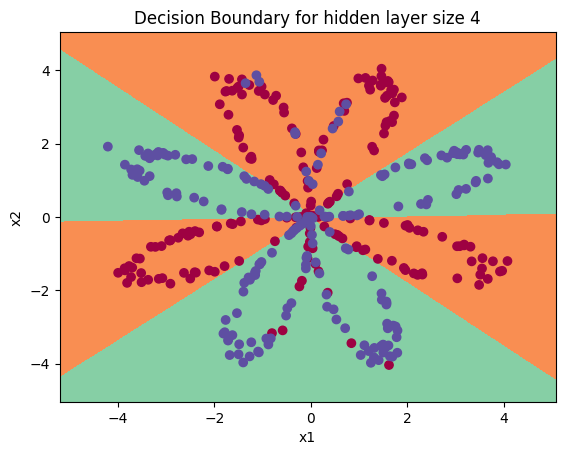

In [20]:
# Build a model with a n_h-dimensional hidden layer
parameters = nn_model(X, y, 4, 1.2 , num_iterations = 10000, print_cost=True)

# Plot the decision boundary
plot_decision_boundary(lambda x: predict(parameters, x.T), X, y)
plt.title("Decision Boundary for hidden layer size " + str(4))

/tmp/ipykernel_16511/351128921.py:18: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  accuracy = float((np.dot(y, predictions.T) + np.dot(1 - y, 1 - predictions.T)) / float(y.shape[1]) * 100)


Accuracy for 1 hidden units: 67.50 %
Accuracy for 2 hidden units: 67.25 %
Accuracy for 3 hidden units: 90.75 %
Accuracy for 4 hidden units: 90.75 %
Accuracy for 5 hidden units: 90.00 %
Accuracy for 20 hidden units: 90.75 %
Accuracy for 50 hidden units: 90.25 %


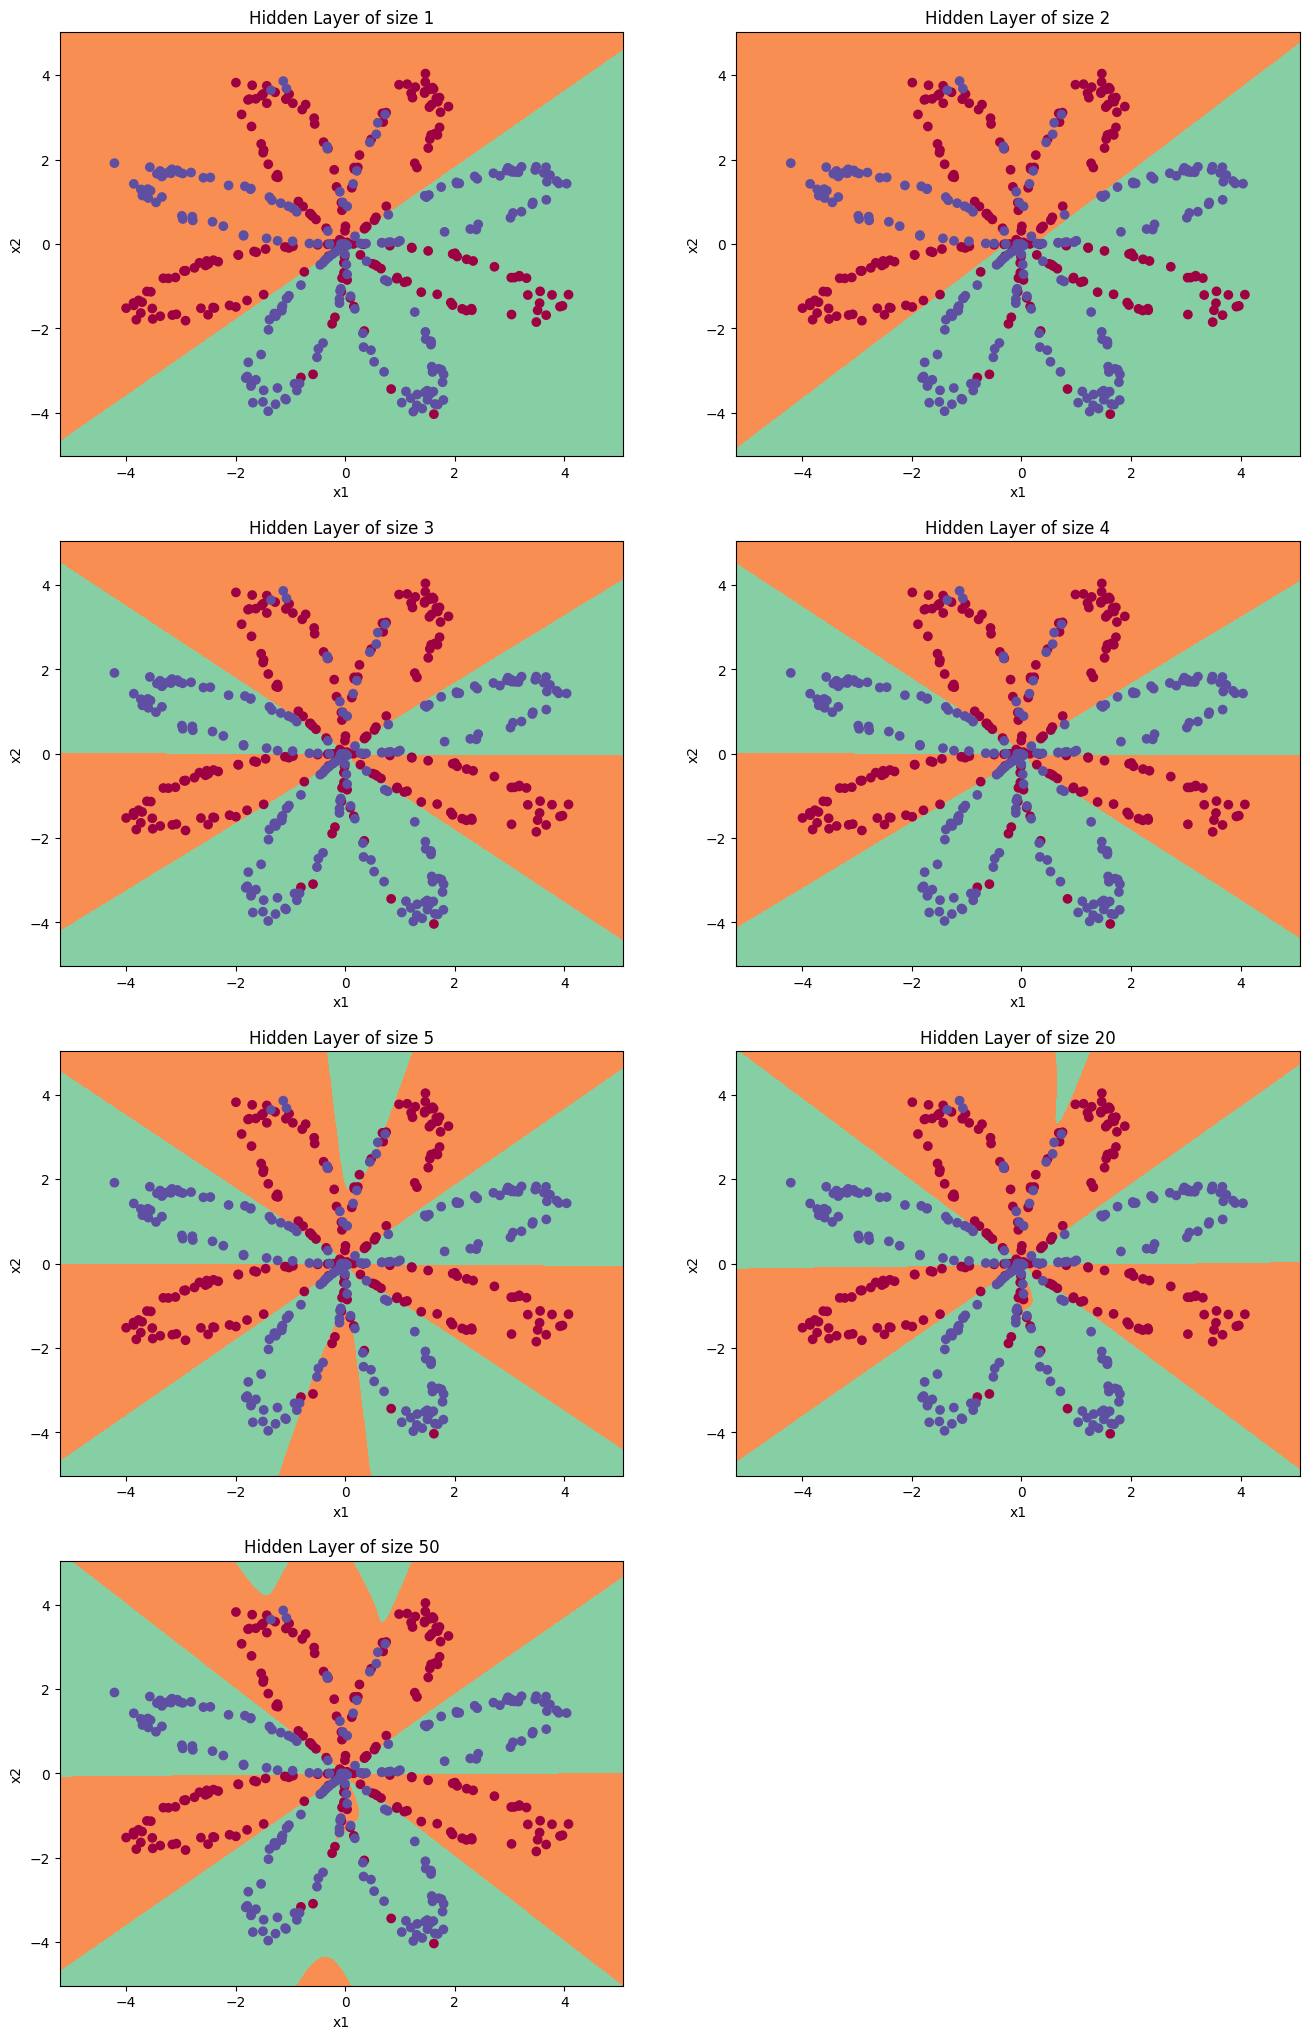

In [23]:
plt.figure(figsize=(16, 32))
hidden_layer_sizes = [1, 2, 3, 4, 5, 20, 50]

for i, n_h in enumerate(hidden_layer_sizes):
    plt.subplot(5, 2, i+1)
    plt.title(f'Hidden Layer of size {n_h}')
    
    # Train the model with the current hidden layer size
    parameters = nn_model(X, y, n_h, 1.2, num_iterations=5000)
    
    # Plot the decision boundary
    plot_decision_boundary(lambda x: predict(parameters, x.T), X, y)
    
    # Make predictions
    predictions = predict(parameters, X)
    
    # Compute accuracy
    accuracy = float((np.dot(y, predictions.T) + np.dot(1 - y, 1 - predictions.T)) / float(y.shape[1]) * 100)
    
    print(f"Accuracy for {n_h} hidden units: {accuracy:.2f} %")